Market volatility is a double-edged sword: it exposes risks and reveals potential opportunities. This measure of price swings over time is a key input for sound investment strategies. Understanding volatility is essential for investors to navigate market complexities effectively.

Source code (this tutorial): https://github.com/quangtiencs/planting_of_a_tree_r360/blob/main/stochastic_volatility_model

## Config

In [1]:
import json
import os

import arviz as az
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

In [2]:
plt.style.use("ggplot")

In [3]:
# cmdstanpy.install_cmdstan()

In [4]:
class StochasticVolatilityConfig:
    SAMPLE = "D"  # "D" for days, "W" for week, "M" for months
    # Stochastic Volatility
    CHAINS = 4
    WARM_UP = 1_000
    NUMBER_SAMPLES = 1_000
    ADAPT_DELTA = 0.95
    ROOT_DIR  = os.path.expanduser("~/SigmaDataset")

In [5]:
try:
    from vector_field.clickhouse import ClickHouseClient
    from vector_field.config import FilePathConfig

    conn = ClickHouseClient()
    df = conn.sql(
        """
        SELECT DATE, CLOSE
        FROM STOCK_MARKET_INDEX
        WHERE MARKET_INDEX = 'VNINDEX'
          AND "DATE" > '2015-04-30'
        ORDER BY DATE
        """
    ).df()
    df.to_csv("vnindex_20250430.csv", index=False)
except Exception as e:
    print("Awww, you can try my demo data")
    df = pd.read_csv("vnindex_20250430.csv")
    df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")

In [6]:
df

,CLOSE
DATE,
2015-05-04,545.080017
2015-05-05,552.650024
2015-05-06,549.299988
2015-05-07,552.979980
2015-05-08,554.510010
...,...
2025-04-23,1211.000000
2025-04-24,1223.349976
2025-04-25,1229.229980


In [7]:
print(
    f"MIN {df.index.min().date()}, MAX {df.index.max().date()}"
)

MIN 2015-05-04, MAX 2025-04-29


<Axes: xlabel='DATE'>

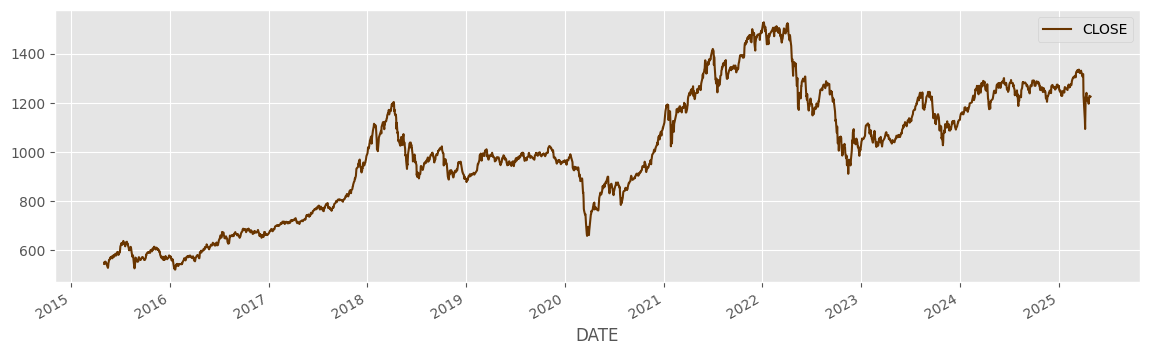

In [8]:
df.plot(figsize=(14, 4), color="#693500")

In [9]:
df_resample = df.resample(StochasticVolatilityConfig.SAMPLE).last()
returns = df_resample.copy()
returns["change"] = np.log(returns["CLOSE"]).diff()
returns = returns.dropna()
returns.head()

,CLOSE,change
DATE,,
2015-05-05,552.650024,0.013793
2015-05-06,549.299988,-0.006080
2015-05-07,552.979980,0.006677
2015-05-08,554.510010,0.002763
2015-05-12,544.409973,-0.013247


In [10]:
# df_resample.plot()

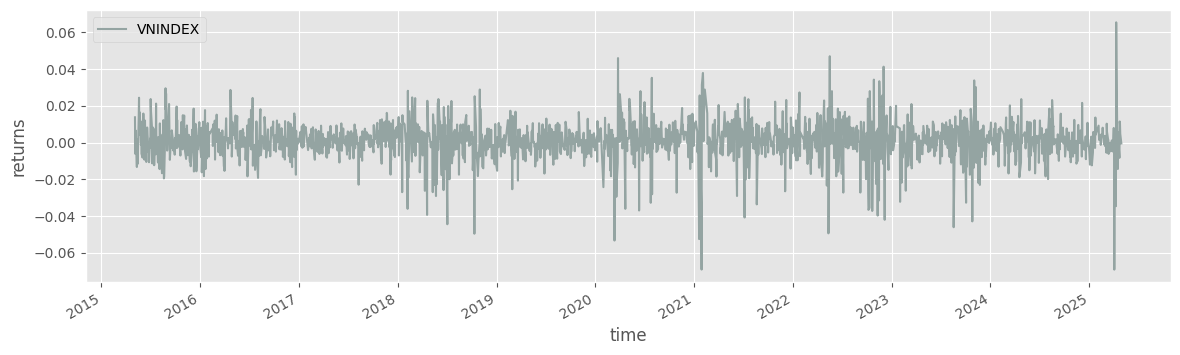

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="change", label="VNINDEX", ax=ax, color="#94a4a2")
ax.set(xlabel="time", ylabel="returns")
ax.legend();

## Model

In [12]:
# this code fork from stan
# https://github.com/stan-dev/example-models/blob/master/misc/moving-avg/stochastic-volatility-optimized.stan
stan_model = """
data {
  int<lower=0> T; // # time points (equally spaced)
  vector[T] y; // mean corrected return at time t
}
parameters {
  real mu; // mean log volatility
  real<lower=-1, upper=1> phi; // persistence of volatility
  real<lower=0> sigma; // white noise shock scale
  vector[T] h_std; // std log volatility time t
}
transformed parameters {
  vector[T] h; // log volatility at time t
  h = h_std * sigma;
  h[1] = h[1] / sqrt(1 - phi * phi);
  h = h + mu;
  for (t in 2 : T) {
    h[t] = h[t] + phi * (h[t - 1] - mu);
  }
}
model {
  sigma ~ cauchy(0, 5);
  mu ~ cauchy(0, 10);
  h_std ~ normal(0, 1);
  y ~ normal(0, exp(h / 2));
}
"""

stan_file = os.path.join(StochasticVolatilityConfig.ROOT_DIR, "stochastic-volatility-optimized.stan")
with open(stan_file, mode="w") as file:
    file.write(stan_model)

In [13]:
data_file = os.path.join(StochasticVolatilityConfig.ROOT_DIR, "vnindex_stochastic_volatility.json")
with open(data_file, mode="w") as file:
    json.dump({"T": len(returns), "y": returns["change"].tolist()}, file)

In [14]:
model = cmdstanpy.CmdStanModel(stan_file=stan_file)
print(model.exe_info())

20:45:11 - cmdstanpy - INFO - compiling stan file /Users/quangtiencs/SigmaDataset/stochastic-volatility-optimized.stan to exe file /Users/quangtiencs/SigmaDataset/stochastic-volatility-optimized
20:45:17 - cmdstanpy - INFO - compiled model executable: /Users/quangtiencs/SigmaDataset/stochastic-volatility-optimized


{'stan_version_major': '2', 'stan_version_minor': '36', 'stan_version_patch': '0', 'STAN_THREADS': 'false', 'STAN_MPI': 'false', 'STAN_OPENCL': 'false', 'STAN_NO_RANGE_CHECKS': 'false', 'STAN_CPP_OPTIMS': 'false'}


In [15]:
fit = model.sample(
    data=data_file,
    chains=StochasticVolatilityConfig.CHAINS,
    iter_sampling=StochasticVolatilityConfig.NUMBER_SAMPLES,
    iter_warmup=StochasticVolatilityConfig.WARM_UP,
    adapt_delta=StochasticVolatilityConfig.ADAPT_DELTA,
    # show_console=False,
    # show_progress=False
)

20:45:18 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:45:39 - cmdstanpy - INFO - CmdStan done processing.
20:45:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'stochastic-volatility-optimized.stan', line 25, column 2 to column 28)
Exception: normal_lpdf: Scale parameter[1] is nan, but must be positive! (in 'stochastic-volatility-optimized.stan', line 25, column 2 to column 28)
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'stochastic-volatility-optimized.stan', line 25, column 2 to column 28)
Exception: normal_lpdf: Scale parameter[1] is nan, but must be positive! (in 'stochastic-volatility-optimized.stan', line 25, column 2 to column 28)
Consider re-running with show_console=True if the above output is unclear!


In [16]:
info_diagnose = str(fit.diagnose())
print(info_diagnose)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [17]:
assert (
        "Processing complete, no problems detected." in info_diagnose
), "There are problems with the model. Check the diagnose output."

## Trace plot

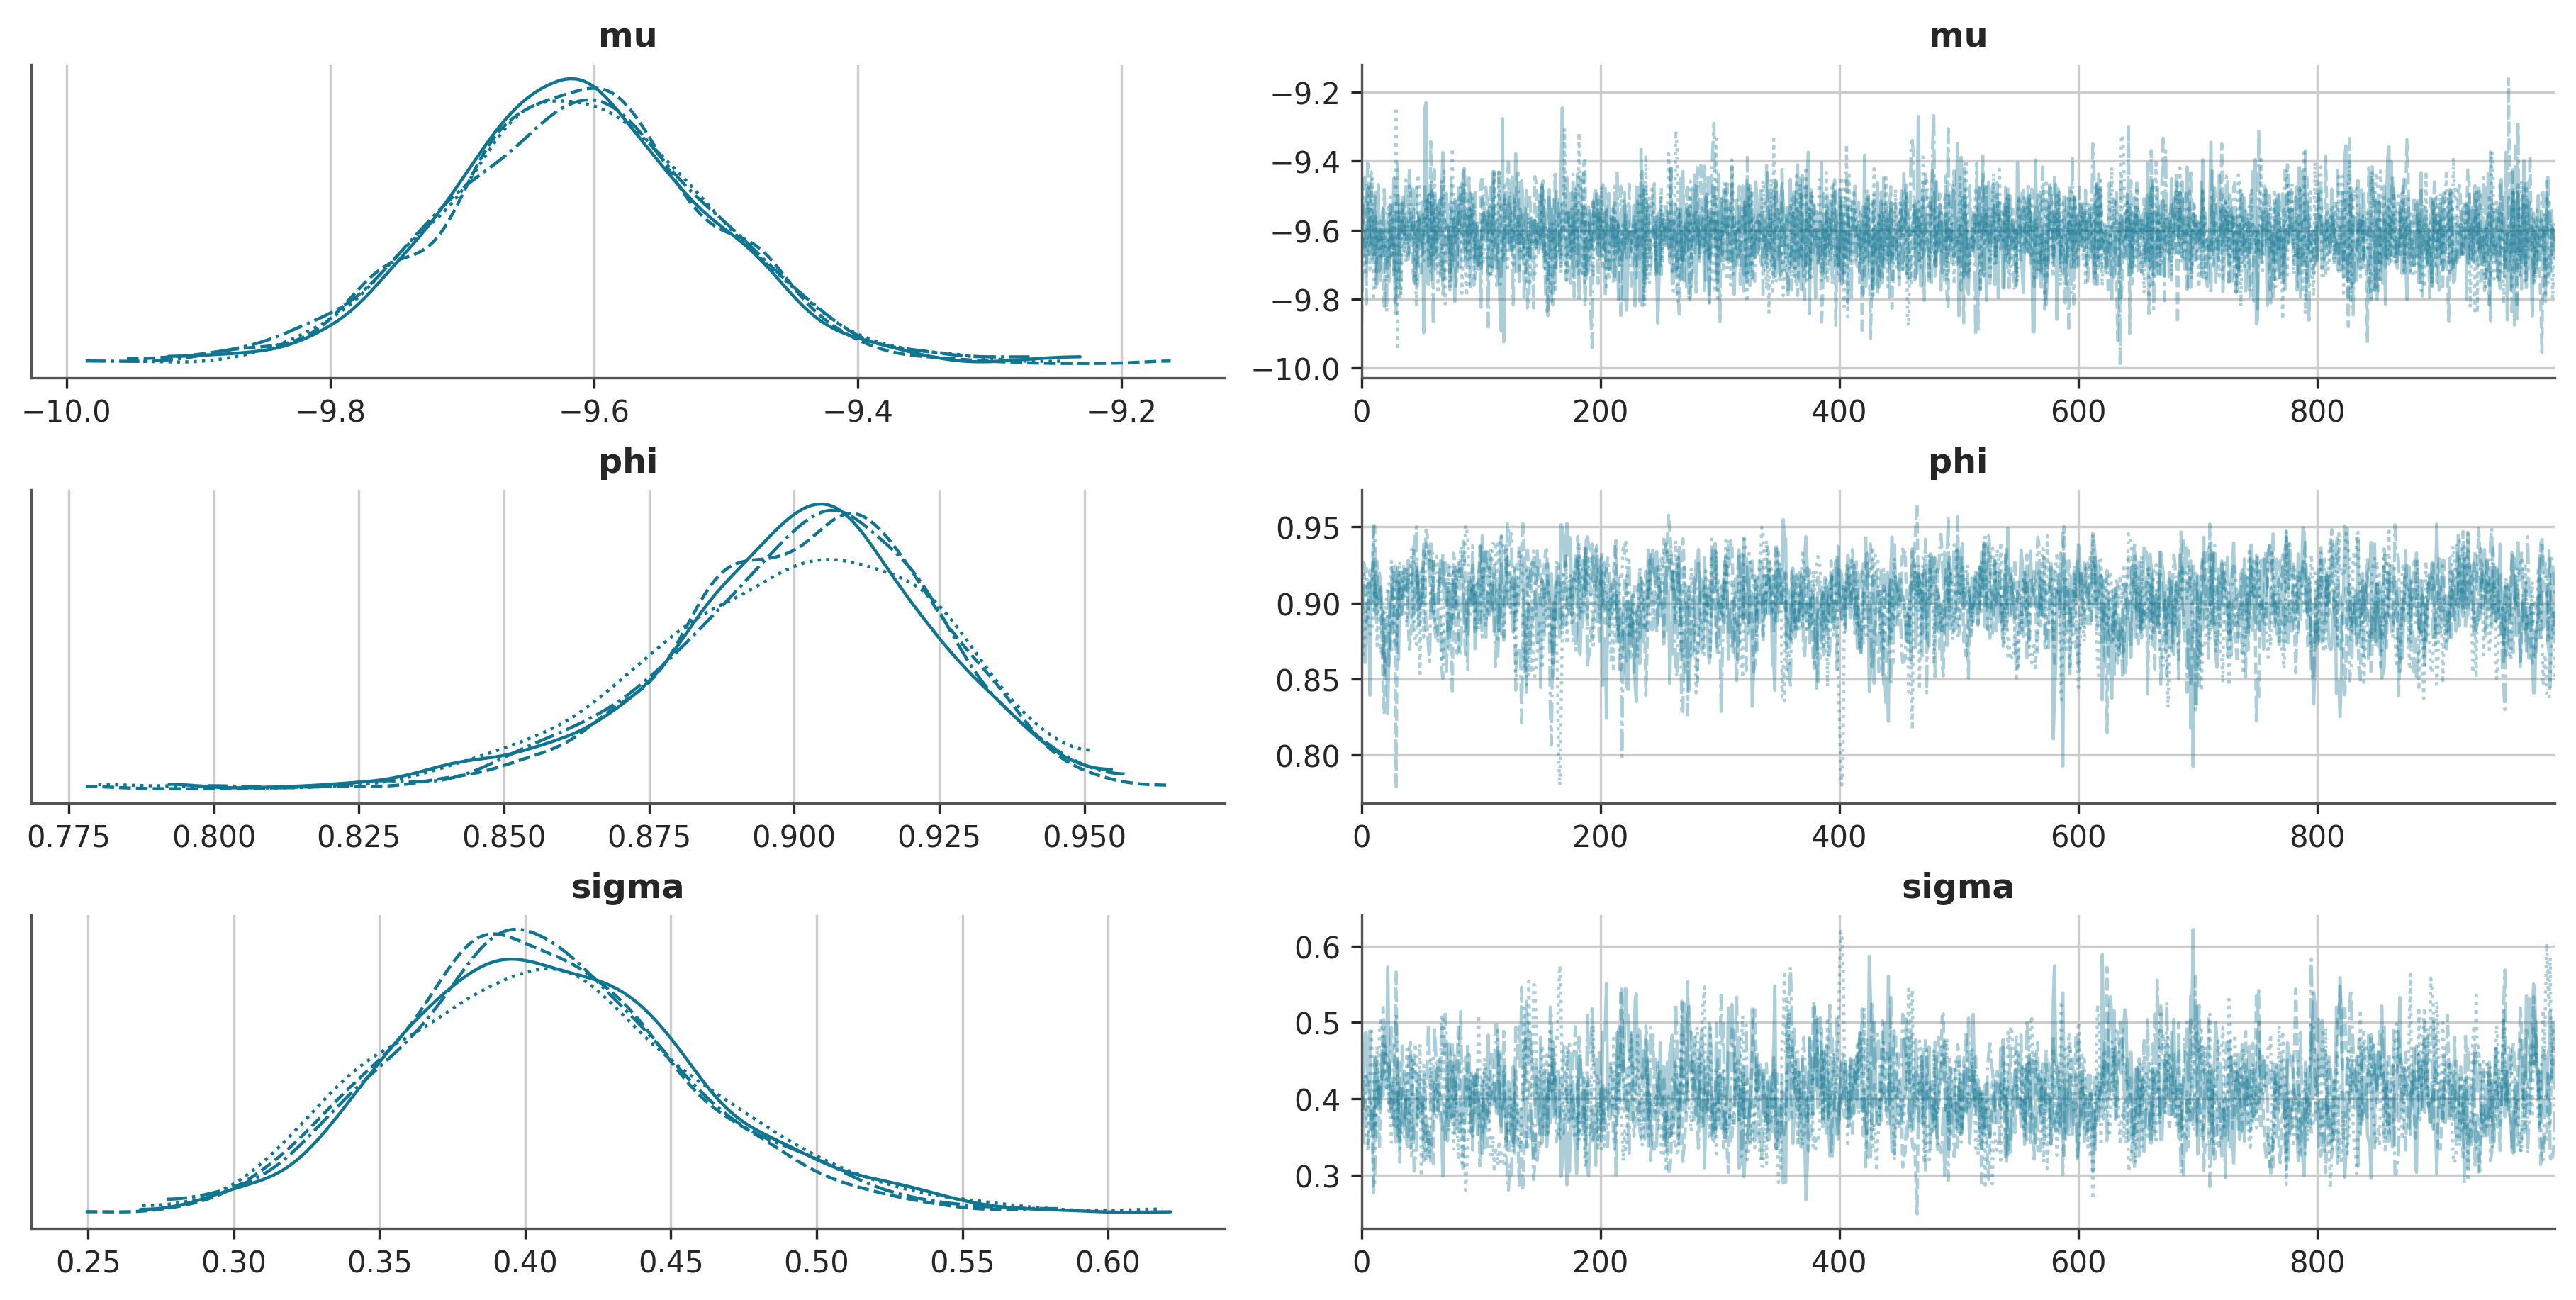

In [18]:
trace = az.from_cmdstanpy(posterior=fit)

with az.style.context("arviz-docgrid", after_reset=True):
    az.plot_trace(trace, var_names=["mu", "phi", "sigma"])

plt.show()

## Stochastic Volatility

/var/folders/kw/nmbc2qy97zxg7r_0gtj0vwqm0000gn/T/ipykernel_15281/2275497795.py:16: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(


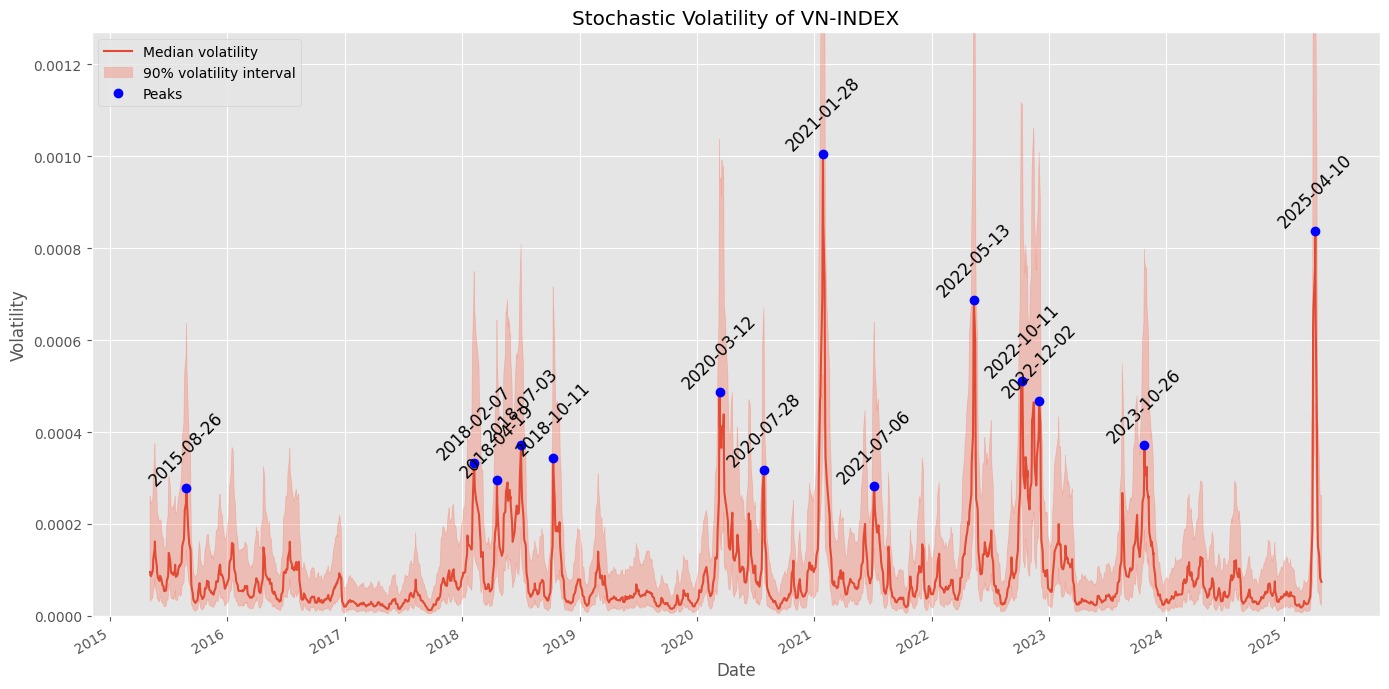

In [19]:
var = "h"
volatility = np.exp(fit.draws_pd(var).T)
median = volatility.quantile(q=0.5, axis=1)
low = volatility.quantile(q=0.05, axis=1)
high = volatility.quantile(q=0.95, axis=1)

peaks, properties = find_peaks(median, height=np.percentile(median, 95), distance=20)

median.index = returns.index

fig, ax = plt.subplots(figsize=(14, 7))
median.plot(ax=ax, label="Median volatility")
ax.fill_between(
    returns.index, low, high, color="tomato", alpha=0.3, label="90% volatility interval"
)
ax.plot(
    median.index.values[peaks], median.values[peaks], "o", label="Peaks", color="blue"
)

# Add annotations for peak dates
for i in peaks:
    peak_date = median.index[i].strftime("%Y-%m-%d")  # Format date nicely
    ax.text(
        median.index[i],
        median.values[i],
        peak_date,
        fontsize=12,
        color="black",
        ha="center",
        va="bottom",
        rotation=45,
    )

plt.legend()

plt.ylim([0, np.percentile(high, 99.3)])
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Stochastic Volatility of VN-INDEX")
plt.tight_layout()
plt.savefig("Stochastic_Volatility_VNINDEX.png")
plt.show()

In [20]:
median.index.values[peaks]

array(['2015-08-26T00:00:00', '2018-02-07T00:00:00',
       '2018-04-19T00:00:00', '2018-07-03T00:00:00',
       '2018-10-11T00:00:00', '2020-03-12T00:00:00',
       '2020-07-28T00:00:00', '2021-01-28T00:00:00',
       '2021-07-06T00:00:00', '2022-05-13T00:00:00',
       '2022-10-11T00:00:00', '2022-12-02T00:00:00',
       '2023-10-26T00:00:00', '2025-04-10T00:00:00'],
      dtype='datetime64[s]')

In [21]:
pd.Series(median.index.values[peaks])

0    2015-08-26
1    2018-02-07
2    2018-04-19
3    2018-07-03
4    2018-10-11
5    2020-03-12
6    2020-07-28
7    2021-01-28
8    2021-07-06
9    2022-05-13
10   2022-10-11
11   2022-12-02
12   2023-10-26
13   2025-04-10
dtype: datetime64[s]

## References

1. Stan Probabilistic Programming. Stochastic-volatility models. https://mc-stan.org/docs/stan-users-guide/time-series.html#stochastic-volatility-models